In [85]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import binned_statistic


1. $q$ and $\omega$ limits for different dm mass with $\omega_{th} = 1$ meV. $\omega_{max}$ depends on $q$, and only $\omega_{max}(q_+/2)$ is listed here. Changing $\omega_{th}$ doesn't change the upper limits of $q$ and $\omega$ much. 
    - $m= 100$ keV: $q\in(0.0004, 0.49)$ keV, $\omega_{max} = 0.0003$ keV $ = 300 $ meV.
    - $m= 10^6$ keV $= 1$ GeV: $q\in(0.0004, 4939.0)$ keV, $\omega_{max} = 3$ keV $ = 3\times10^6$ meV. 

$\bar\omega = 13$ meV, DM mass range 100 keV ~ 10^6 keV 

In [86]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list,omega_threshold,s_factor,cross_section):
        c = 2.998e5 #in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_val = q_val
        self.omega_list = omega_list 
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold # detector threshold. keV
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        self.num_density = 2.15e25 # per kg
        # unit conversion, ref: https://physics.nist.gov/cuu/Constants/energy.html
        self.keV2InvS = 2.418e17 # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6

    def get_v_min(self, mass_DM, q,):
        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral


    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    def _get_omega_mask(self,):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    
    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val
            return constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask]) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg # per kg-year-keV
    
    def get_v_min_nr(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return np.sqrt(28*self.mass_proton * self.omega_list / (2*reducedMass))
        
    def get_inverse_mean_func_nr(self,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min_nr()
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))

    def get_nr_diff_rate_dRdq(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return self.num_density * (self.density_DM / self.mass_DM) * (self.cross_section*(self.mass_proton*28)/(2*reducedMass**2)) * 28**2 * self.get_inverse_mean_func_nr()

In [87]:
def get_impulse_approx(q, omega_list, omega_avg=30e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


$$q_\pm \equiv m_\chi v \bigg(1\pm \sqrt{1-\frac{2\omega_{th}}{m_\chi v^2}}\bigg) $$
$$\omega_+ \equiv qv -\frac{q^2}{2m_\chi}$$

Long wavelength approximation valid for $q<q_{BZ}\approx 2m_\chi v$, $m_\chi<q_{BZ}/2v=1.14/(2*0.00247)=230$ keV

In [88]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [120]:
nSiteData = np.load("nSiteSFactor_lwa_finer.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
s_factor_nSite_incoh_lwa = nSiteData["s_lwa"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]

Text(0.5, 0, '$\\omega$ [meV]')

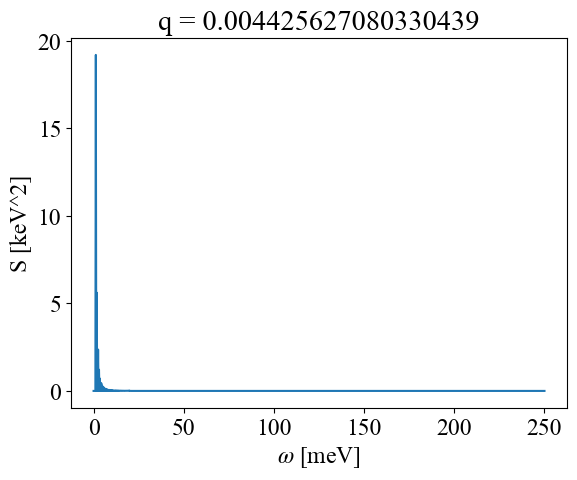

In [111]:
i = 200
plt.plot(omega_list_nSite*1e6, s_factor_nSite[i])
plt.title(f"q = {q_list_nSite[i]}")
plt.ylabel('S [keV^2]')
plt.xlabel(r'$\omega$ [meV]')
# plt.ylim(-0.05e8, .6e8)
# plt.xlim(0,150)

Replace incoherent approximation with long wavelength approx for q<q_bz

In [112]:
np.pi/(2*np.pi/2.28)

1.14

In [114]:
2*np.pi*28**2/(latticeConst**3)*q_lwa**2/(2*26161e3*omega_lwa)/(omega_list_nSite[1]-omega_list_nSite[0])


array([2.60925787e+02, 2.64080648e+02, 2.67273654e+02, 2.70505267e+02,
       2.73775954e+02, 2.77086186e+02, 2.80436443e+02, 2.83827208e+02,
       2.87258970e+02, 2.90732227e+02, 2.94247478e+02, 2.97805232e+02,
       3.01406004e+02, 3.05050312e+02, 3.08738684e+02, 3.12471652e+02,
       3.16249755e+02, 3.20073540e+02, 3.23943558e+02, 3.27860369e+02,
       3.31824538e+02, 3.35836638e+02, 3.39897248e+02, 3.44006955e+02,
       3.48166353e+02, 3.52376042e+02, 3.56636631e+02, 3.60948734e+02,
       3.65312976e+02, 3.69729985e+02, 3.74200401e+02, 3.78724869e+02,
       3.83304042e+02, 3.87938583e+02, 3.92629159e+02, 3.97376450e+02,
       4.02181140e+02, 4.07043924e+02, 4.11965504e+02, 4.16946591e+02,
       4.21987904e+02, 4.27090172e+02, 4.32254132e+02, 4.37480530e+02,
       4.42770120e+02, 4.48123666e+02, 4.53541943e+02, 4.59025732e+02,
       4.64575826e+02, 4.70193026e+02, 4.75878144e+02, 4.81632001e+02,
       4.87455428e+02, 4.93349267e+02, 4.99314368e+02, 5.05351593e+02,
      

In [115]:
cross_section = 1e-40 # cm^2
omega_avg = 13.13e-6


### Intermediate step: dR/dq

In [116]:
dm_length = 200
dmmasslist_4plot = np.array([100,1e3, 40e3, 100e3, 1e6]) # 10^2 ~ 10^6 keV
omega_threshold = 1e-6 # keV

dRdq_result_4plot = []
dRdq_result_incoh_4plot = []
dRdq_result_incoh_lwa_4plot = []
qlist_4plot = []
    
rate_result = np.empty(dm_length)
rate_result_incoh = np.empty(dm_length)
for ind_m, dmmass in enumerate(dmmasslist_4plot):    
    if ind_m%10 == 0: print(f'processing {ind_m}...')
    q_min, q_max = get_q_lim(dmmass, omega_threshold)
    if q_max < q_list_nSite[-1]:
        qlist = q_list_nSite
        dRdq_result = np.empty(len(q_list_nSite))
        dRdq_result_incoh = np.empty(len(q_list_nSite))
        dRdq_result_incoh_lwa = np.empty(len(q_list_nSite))
        for ind_q, q in enumerate(qlist): 
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
            dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh_lwa[ind_q], cross_section)
            dRdq_result_incoh_lwa[ind_q] = rateCal.get_diff_rate_dRdq()
    else: 
        omega_length=4000
        q_length=100
        qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length+1)[1:]))
        dRdq_result = np.empty(q_length+len(q_list_nSite))
        dRdq_result_incoh = np.empty(q_length+len(q_list_nSite))
        dRdq_result_incoh_lwa = np.empty(q_length+len(q_list_nSite))
        for ind_q, q in enumerate(q_list_nSite): 
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
            dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh_lwa[ind_q], cross_section)
            dRdq_result_incoh_lwa[ind_q] = rateCal.get_diff_rate_dRdq()
        for ind_q, q in enumerate(qlist[len(q_list_nSite):]): 
            omega_max = get_omega_lim(dmmass, q)
            omegalist = np.linspace(omega_threshold,omega_max , omega_length)
            s_factor_ia = get_impulse_approx(q, omegalist, omega_avg=omega_avg,)
            rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
            dRdq_result[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
            dRdq_result_incoh[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
            dRdq_result_incoh_lwa[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()

    dRdq_result_4plot.append(dRdq_result)
    dRdq_result_incoh_4plot.append(dRdq_result_incoh)
    dRdq_result_incoh_lwa_4plot.append(dRdq_result_incoh_lwa)

    qlist_4plot.append(qlist)
    # rate_result[ind_m] = sp.integrate.simpson(dRdq_result, qlist) # per kg-year
    # rate_result_incoh[ind_m] = sp.integrate.simpson(dRdq_result_incoh, qlist)

processing 0...


In [117]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})


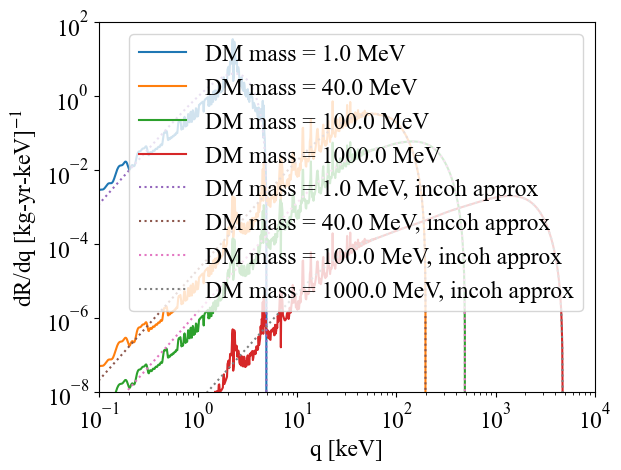

In [118]:
for i in range(1,5):
    plt.plot(qlist_4plot[i], dRdq_result_4plot[i], label=f'DM mass = {dmmasslist_4plot[i]/1e3:.1f} MeV')
for i in range(1,5):
    plt.plot(qlist_4plot[i], dRdq_result_incoh_4plot[i], label=f'DM mass = {dmmasslist_4plot[i]/1e3:.1f} MeV, incoh approx',linestyle=':')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-8, 100)
plt.xlim(0.1,1e4)
plt.xlabel('q [keV]')
plt.ylabel('dR/dq [kg-yr-keV]$^{-1}$')
plt.legend()
plt.show()

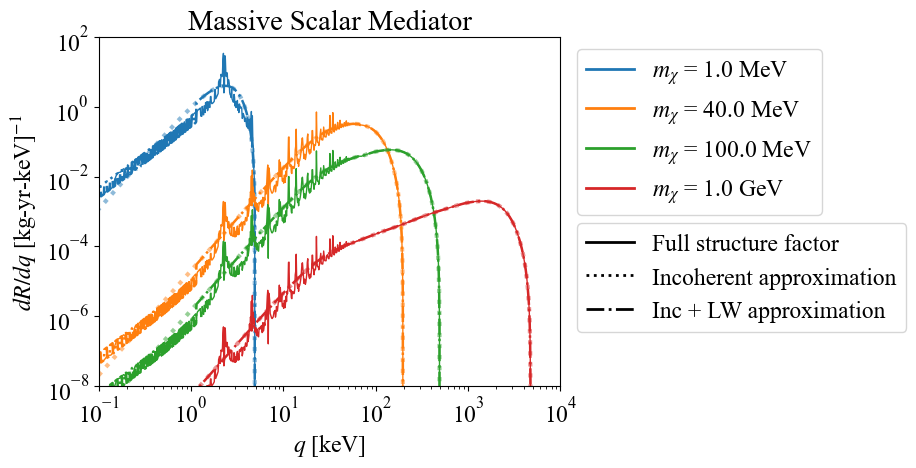

In [119]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Define 4 distinct colors for the 4 different masses
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

plt.figure(figsize=(9.5,5))

for i in range(1, 5):
    c = colors[i-1] 
    plt.plot(qlist_4plot[i], dRdq_result_4plot[i], color=c, linestyle='-',lw=1)
    plt.plot(qlist_4plot[i], dRdq_result_incoh_4plot[i], color=c, linestyle=':', lw=3,alpha=.5)
    plt.plot(qlist_4plot[i], dRdq_result_incoh_lwa_4plot[i], color=c, linestyle='-.',lw=1.8)


plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-8, 1e2)
plt.xlim(0.1, 1e4)
plt.xlabel('$q$ [keV]')
plt.ylabel('$dR/dq$ [kg-yr-keV]$^{-1}$')

# --- Creating the Two Legends ---

mass_handles = []
for i in range(1, 5):
    if i==4:
        mass_label = f'$m_\chi$ = {dmmasslist_4plot[i]/1e6:.1f} GeV'
        mass_handles.append(Line2D([0], [0], color=colors[i-1], lw=2, label=mass_label))

    else:
        mass_label = f'$m_\chi$ = {dmmasslist_4plot[i]/1e3:.1f} MeV'
        mass_handles.append(Line2D([0], [0], color=colors[i-1], lw=2, label=mass_label))

method_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='Full structure factor'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='Incoherent approximation'),
    Line2D([0], [0], color='black', lw=2, linestyle='-.', label='Inc + LW approximation')

]

# 1. Place the first legend outside, anchored to the top right
leg1 = plt.legend(handles=mass_handles, title="", 
                  loc='upper left', bbox_to_anchor=(1.01, 1))
plt.gca().add_artist(leg1)

# 2. Place the second legend outside, anchored below the first one
plt.legend(handles=method_handles,
           loc='upper left', bbox_to_anchor=(1.01, 0.5))
plt.title("Massive Scalar Mediator")

# Adjust layout so the legends are not cut off by the edge of the image
plt.tight_layout()

plt.show()

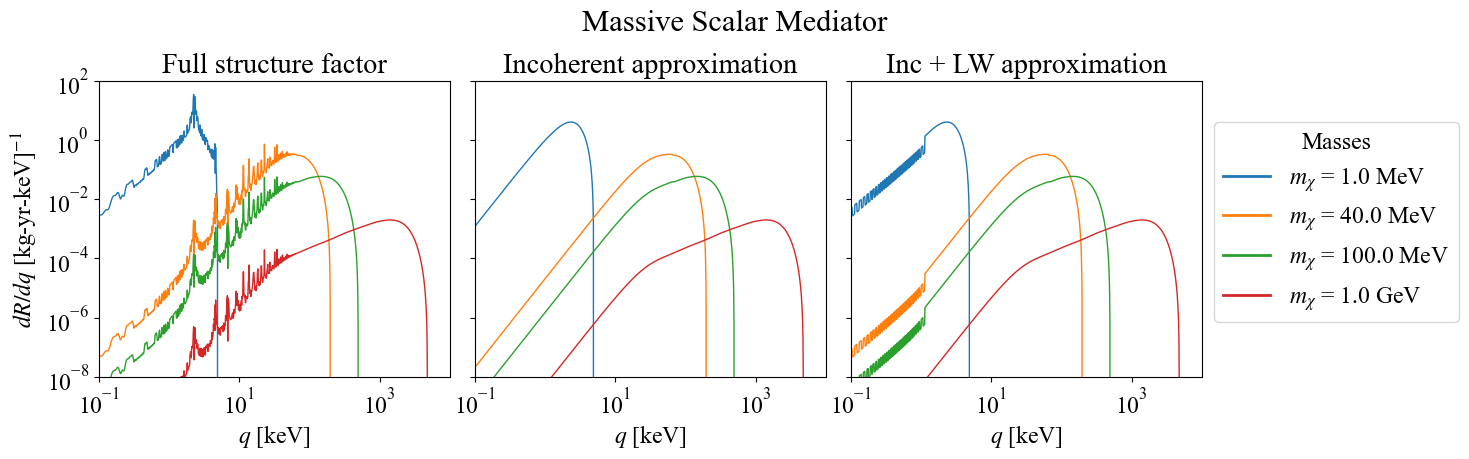

In [142]:
# Define 4 distinct colors for the 4 different masses
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Create a figure with 3 subplots in one row. 'sharey=True' keeps the y-axis the same for all.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Set common configurations for all subplots
titles = ['Full structure factor', 'Incoherent approximation', 'Inc + LW approximation']

for j in range(3):
    axes[j].set_title(titles[j])
    axes[j].set_xscale('log')
    axes[j].set_yscale('log')
    axes[j].set_ylim(1e-8, 1e2)
    axes[j].set_xlim(0.1, 1e4)
    axes[j].set_xlabel('$q$ [keV]')

# Only set the y-label on the leftmost plot
axes[0].set_ylabel('$dR/dq$ [kg-yr-keV]$^{-1}$')

# Plot the lines on their respective subplots
for i in range(1, 5):
    c = colors[i-1] 
    
    # Plotting using the same solid line style and thickness for all
    axes[0].plot(qlist_4plot[i], dRdq_result_4plot[i], color=c, linestyle='-', lw=1.)
    axes[1].plot(qlist_4plot[i], dRdq_result_incoh_4plot[i], color=c, linestyle='-', lw=1.)
    axes[2].plot(qlist_4plot[i], dRdq_result_incoh_lwa_4plot[i], color=c, linestyle='-', lw=1.)


# --- Creating the Mass Legend ---
mass_handles = []
for i in range(1, 5):
    if i == 4:
        mass_label = f'$m_\chi$ = {dmmasslist_4plot[i]/1e6:.1f} GeV'
        mass_handles.append(Line2D([0], [0], color=colors[i-1], lw=2, label=mass_label))
    else:
        mass_label = f'$m_\chi$ = {dmmasslist_4plot[i]/1e3:.1f} MeV'
        mass_handles.append(Line2D([0], [0], color=colors[i-1], lw=2, label=mass_label))

# Place the single legend outside the 3rd (rightmost) subplot
axes[2].legend(handles=mass_handles, title="Masses",
               loc='upper left', bbox_to_anchor=(1.0, .9))

# Overall figure title
fig.suptitle("Massive Scalar Mediator", fontsize=22, y=.93)

# Adjust layout so the titles and legend aren't clipped
plt.tight_layout()
plt.subplots_adjust(wspace=0.07)
plt.show()

### Long wavelength approx only ($m_\chi < 230$ keV)

In [99]:
def get_lw(omega_threshold = 1e-6):
    dm_length = 40
    dmmasslist = 10**np.linspace(1, 2.36, dm_length) # keV
    
    rate_result_lwa = np.empty(dm_length)

    for ind_m, dmmass in enumerate(dmmasslist):    
        if ind_m%10 == 0: print(f'processing {ind_m}...')
        q_min, q_max = get_q_lim(dmmass, omega_threshold)
        if q_max < q_lwa[-1]:
            qlist = q_lwa
            dRdq_result = np.empty(len(q_lwa))
            for ind_q, q in enumerate(qlist): 
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_lwa[ind_q], cross_section)
                dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
        rate_result_lwa[ind_m] = sp.integrate.simpson(dRdq_result, q_lwa) # per kg-year
    return rate_result_lwa

In [100]:
# dm_length = 40
# dmmasslist = 10**np.linspace(1, 2.36, dm_length) # keV
# omega_threshold = 1e-6 # keV

# rate_result_lwa = np.empty(dm_length)

# for ind_m, dmmass in enumerate(dmmasslist):    
#     if ind_m%10 == 0: print(f'processing {ind_m}...')
#     q_min, q_max = get_q_lim(dmmass, omega_threshold)
#     if q_max < q_lwa[-1]:
#         qlist = q_lwa
#         dRdq_result = np.empty(len(q_lwa))
#         for ind_q, q in enumerate(qlist): 
#             rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_lwa[ind_q], cross_section)
#             dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
#     rate_result_lwa[ind_m] = sp.integrate.simpson(dRdq_result, q_lwa) # per kg-year
    
rate_result_lwa = get_lw(1e-6)
rate_result_lwa_th10 = get_lw(10e-6)
rate_result_lwa_th20 = get_lw(20e-6)

processing 0...
processing 10...
processing 20...
processing 30...
processing 0...
processing 10...
processing 20...
processing 30...
processing 0...
processing 10...
processing 20...
processing 30...


### Cut: 1 meV

In [121]:
def get_all_rates(omega_threshold = 1e-6):
    dm_length = 200
    dmmasslist = 10**np.linspace(1, 6, dm_length) # keV

    rate_result = np.empty(dm_length)
    rate_result_incoh = np.empty(dm_length)
    rate_result_incoh_lwa = np.empty(dm_length)

    for ind_m, dmmass in enumerate(dmmasslist):    
        if ind_m%10 == 0: print(f'processing {ind_m}...')
        q_min, q_max = get_q_lim(dmmass, omega_threshold)
        if q_max < q_list_nSite[-1]:
            qlist = q_list_nSite
            dRdq_result = np.empty(len(q_list_nSite))
            dRdq_result_incoh = np.empty(len(q_list_nSite))
            dRdq_result_incoh_lwa = np.empty(len(q_list_nSite))
            for ind_q, q in enumerate(qlist): 
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
                dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
                dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh_lwa[ind_q], cross_section)
                dRdq_result_incoh_lwa[ind_q] = rateCal.get_diff_rate_dRdq()
        else: 
            omega_length=2000
            q_length=1000
            qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length+1)[1:]))
            dRdq_result = np.empty(q_length+len(q_list_nSite))
            dRdq_result_incoh = np.empty(q_length+len(q_list_nSite))
            dRdq_result_incoh_lwa = np.empty(q_length+len(q_list_nSite))
            for ind_q, q in enumerate(q_list_nSite): 
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
                dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
                dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh_lwa[ind_q], cross_section)
                dRdq_result_incoh_lwa[ind_q] = rateCal.get_diff_rate_dRdq()
            for ind_q, q in enumerate(qlist[len(q_list_nSite):]): 
                omega_max = get_omega_lim(dmmass, q)
                omegalist = np.linspace(omega_threshold,omega_max , omega_length)
                s_factor_ia = get_impulse_approx(q, omegalist, omega_avg=omega_avg,)
                rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
                dRdq_result[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
                dRdq_result_incoh[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
                dRdq_result_incoh_lwa[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
        rate_result[ind_m] = sp.integrate.simpson(dRdq_result, qlist) # per kg-year
        rate_result_incoh[ind_m] = sp.integrate.simpson(dRdq_result_incoh, qlist) # per kg-year
        rate_result_incoh_lwa[ind_m] = sp.integrate.simpson(dRdq_result_incoh_lwa, qlist) # per kg-year
    return rate_result, rate_result_incoh, rate_result_incoh_lwa

In [122]:
rate_result, rate_result_incoh, rate_result_incoh_lwa = get_all_rates(1e-6)
rate_result_th10, rate_result_incoh_th10, rate_result_incoh_lwa_th10 = get_all_rates(10e-6)
rate_result_th20, rate_result_incoh_th20, rate_result_incoh_lwa_th20 = get_all_rates(20e-6)

processing 0...
processing 10...
processing 20...
processing 30...
processing 40...
processing 50...
processing 60...
processing 70...
processing 80...
processing 90...
processing 100...
processing 110...
processing 120...
processing 130...
processing 140...
processing 150...
processing 160...
processing 170...
processing 180...
processing 190...
processing 0...
processing 10...
processing 20...
processing 30...
processing 40...
processing 50...
processing 60...
processing 70...
processing 80...
processing 90...
processing 100...
processing 110...
processing 120...
processing 130...
processing 140...
processing 150...
processing 160...
processing 170...
processing 180...
processing 190...
processing 0...
processing 10...
processing 20...
processing 30...
processing 40...
processing 50...
processing 60...
processing 70...
processing 80...
processing 90...
processing 100...
processing 110...
processing 120...
processing 130...
processing 140...
processing 150...
processing 160...
process

Isotropic rate:
$ R = \frac{1}{\rho_T}\frac{\rho_\chi}{m_\chi}\int \frac{q\,dq}{(2\pi)^2}d\omega\,\eta(v_{min}(q,\omega))\times\frac{\pi\bar\sigma(q)}{\mu^2_\chi}\times S(q,\omega) $

Differential rate: 
$ \frac{dR}{dq} = \frac{1}{\rho_T}\frac{\rho_\chi}{m_\chi}\frac{\pi\bar\sigma(q)}{\mu^2_\chi}\frac{q}{(2\pi)^2}\int d\omega\,\eta(v_{min}(q,\omega))\times S(q,\omega) $        
                                                                                           

In [123]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

In [124]:
# rateCal = RateCalculations(dmmass, None, omegalist, omega_threshold, None, cross_section)
# # rate_result_nr = rateCal.get_nr_limit()
# # plt.plot(dmmasslist, rate_result_nr)
# rateCal.get_v_min_nr().shape

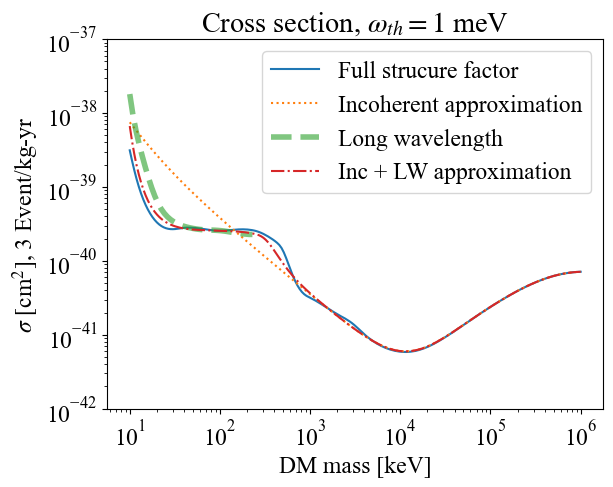

In [125]:
dm_length = 200 
dmmasslist = 10**np.linspace(1, 6, dm_length) # keV

plt.plot(dmmasslist, 3*cross_section/rate_result,label='Full strucure factor')
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh,label='Incoherent approximation', linestyle=':')
plt.plot(10**np.linspace(1, 2.36, 40), 3*cross_section/rate_result_lwa, label="Long wavelength", linestyle="--",lw=4,alpha=0.6)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa,label='Inc + LW approximation', linestyle='-.')

plt.title('Cross section, $\omega_{th}=1$ meV')
plt.yscale('log')
plt.xscale('log')
plt.ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")
plt.xlabel('DM mass [keV]')
plt.ylim(1e-42, 1e-37)
plt.legend()

C:\Users\xylin\AppData\Local\Temp\ipykernel_54868\998603831.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot(10**np.linspace(1, 2.36, 40), 3*cross_section/rate_result_lwa_th10, label="Long wavelength", linestyle="--",lw=4,alpha=0.6)


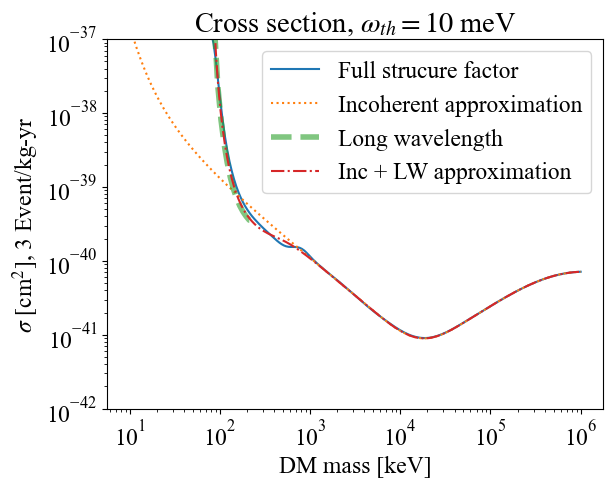

In [127]:
dm_length = 200
dmmasslist = 10**np.linspace(1, 6, dm_length) # keV

plt.plot(dmmasslist, 3*cross_section/rate_result_th10,label='Full strucure factor')
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_th10,label='Incoherent approximation', linestyle=':')
plt.plot(10**np.linspace(1, 2.36, 40), 3*cross_section/rate_result_lwa_th10, label="Long wavelength", linestyle="--",lw=4,alpha=0.6)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa_th10,label='Inc + LW approximation', linestyle='-.')

plt.title('Cross section, $\omega_{th}=10$ meV')
plt.yscale('log')
plt.xscale('log')
plt.ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")
plt.xlabel('DM mass [keV]')
plt.ylim(1e-42, 1e-37)
plt.legend()

C:\Users\xylin\AppData\Local\Temp\ipykernel_54868\2052963006.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot(20**np.linspace(1, 2.36, 40), 3*cross_section/rate_result_lwa_th20, label="Long wavelength", linestyle="--",lw=4,alpha=0.6)


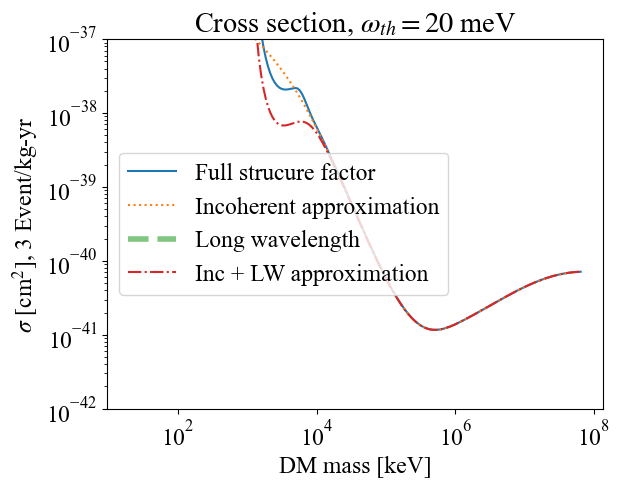

In [128]:
dm_length = 200
dmmasslist = 20**np.linspace(1, 6, dm_length) # keV

plt.plot(dmmasslist, 3*cross_section/rate_result_th20,label='Full strucure factor')
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_th20,label='Incoherent approximation', linestyle=':')
plt.plot(20**np.linspace(1, 2.36, 40), 3*cross_section/rate_result_lwa_th20, label="Long wavelength", linestyle="--",lw=4,alpha=0.6)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa_th20,label='Inc + LW approximation', linestyle='-.')

plt.title('Cross section, $\omega_{th}=20$ meV')
plt.yscale('log')
plt.xscale('log')
plt.ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")
plt.xlabel('DM mass [keV]')
plt.ylim(1e-42, 1e-37)
plt.legend()

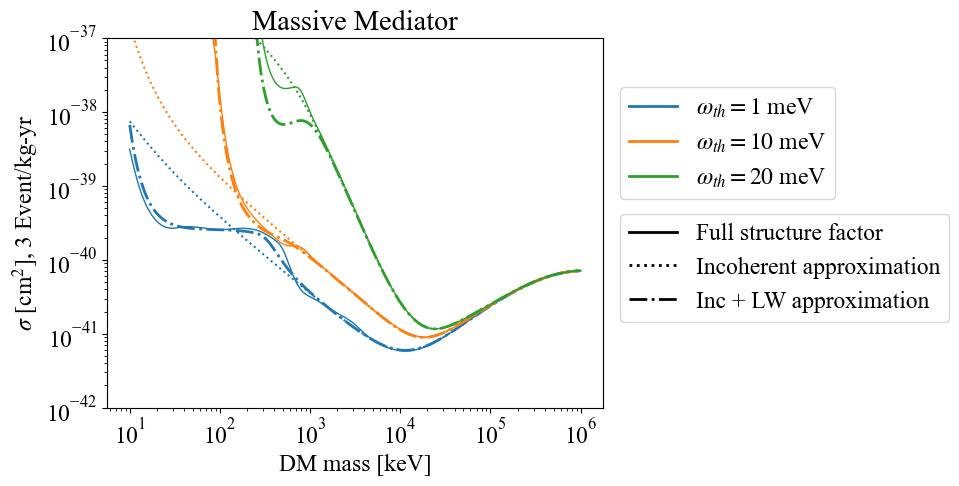

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

dm_length = 200 
dmmasslist = 10**np.linspace(1, 6, dm_length) # keV

# Define our visual properties to keep things organized
colors = {'th1': 'tab:blue', 'th10': 'tab:orange', 'th20': 'tab:green'}
styles = {'full': '-', 'incoh': ':', 'incoh_lwa': '-.'}

# 1. Plot threshold 1 (1 meV) - Blue
plt.plot(dmmasslist, 3*cross_section/rate_result, color=colors['th1'], linestyle=styles['full'], lw=1)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh, color=colors['th1'], linestyle=styles['incoh'])
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa, color=colors['th1'], linestyle=styles['incoh_lwa'], lw=2)

# 2. Plot threshold 10 - Orange
plt.plot(dmmasslist, 3*cross_section/rate_result_th10, color=colors['th10'], linestyle=styles['full'], lw=1)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_th10, color=colors['th10'], linestyle=styles['incoh'])
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa_th10, color=colors['th10'], linestyle=styles['incoh_lwa'],lw=2)

# 3. Plot threshold 20 - Green
plt.plot(dmmasslist, 3*cross_section/rate_result_th20, color=colors['th20'], linestyle=styles['full'], lw=1)
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_th20, color=colors['th20'], linestyle=styles['incoh'])
plt.plot(dmmasslist, 3*cross_section/rate_result_incoh_lwa_th20, color=colors['th20'], linestyle=styles['incoh_lwa'],lw=2)

# --- Custom Legends Setup ---

# Create "proxy artists" (dummy lines) for the Threshold legend (varying colors, solid line)
legend_thresholds = [
    Line2D([0], [0], color=colors['th1'], lw=2, label='$\omega_{th}=1$ meV'),
    Line2D([0], [0], color=colors['th10'], lw=2, label='$\omega_{th}=10$ meV'),
    Line2D([0], [0], color=colors['th20'], lw=2, label='$\omega_{th}=20$ meV')
]

# Create "proxy artists" for the Approximation legend (all black, varying styles)
legend_approximations = [
    Line2D([0], [0], color='black', lw=2, linestyle=styles['full'], label='Full structure factor'),
    Line2D([0], [0], color='black', lw=2, linestyle=styles['incoh'], label='Incoherent approximation'),
    Line2D([0], [0], color='black', lw=2, linestyle=styles['incoh_lwa'], label='Inc + LW approximation')
]

# Get the current axes
ax = plt.gca()

# 1st Legend (Thresholds): Aligns the upper-left of the legend to just outside the top-right of the plot
leg1 = ax.legend(handles=legend_thresholds, loc='upper left', bbox_to_anchor=(1.01, .9), )
ax.add_artist(leg1) 

# 2nd Legend (Approximations): Aligns the lower-left of the legend to just outside the bottom-right of the plot
ax.legend(handles=legend_approximations, loc='lower left', bbox_to_anchor=(1.01, .2), )


# --- Plot Formatting ---
plt.title('Massive Mediator')
plt.yscale('log')
plt.xscale('log')
plt.ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")
plt.xlabel('DM mass [keV]')
plt.ylim(1e-42, 1e-37)

plt.show()

In [109]:
# Save all calculated variables to an .npz file
np.savez('dm_rate_results_massive.npz', 
         dmmasslist=dmmasslist, 
         cross_section=cross_section,
         rate_result=rate_result, 
         rate_result_incoh=rate_result_incoh, 
         rate_result_incoh_lwa=rate_result_incoh_lwa,
         rate_result_th10=rate_result_th10, 
         rate_result_incoh_th10=rate_result_incoh_th10, 
         rate_result_incoh_lwa_th10=rate_result_incoh_lwa_th10,
         rate_result_th20=rate_result_th20, 
         rate_result_incoh_th20=rate_result_incoh_th20, 
         rate_result_incoh_lwa_th20=rate_result_incoh_lwa_th20)

print("Results successfully saved to dm_rate_results.npz")

Results successfully saved to dm_rate_results.npz
